In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
df = pd.read_csv('../data/q3_retail_promotions.csv')
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [3]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

In [4]:
#feature engineering
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

df['is_month_end'] = df['transaction_date'].dt.day.apply(lambda x: 1 if x >= 25 else 0)

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


New time based features such as year, month, and day of week were extracted from the transaction date
An additional feature, is_month_end, was created to capture potential increases in sales toward the End of the month.

In [5]:
#Sort data
df = df.sort_values(by='transaction_date')

In [6]:
#Train-Test Split TIME BASED
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

Train size: (960, 13)
Test size: (240, 13)


A time based split is used instead of a random split to prevent Data leakage.
Since the data is time dependent using future data in training would lead to unrealistic model performance

In [7]:
#Separate Features & Target
X_train = train_df.drop(['items_sold', 'transaction_date'], axis=1)
y_train = train_df['items_sold']

X_test = test_df.drop(['items_sold', 'transaction_date'], axis=1)
y_test = test_df['items_sold']

In [8]:
categorical_cols = ['promotion_type', 'location_type', 'store_size']

numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

In [9]:
#preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)

A preprocessing pipeline is used to ensure consistent transformations.
Categorical variables are one-hot encoded and numerical variables are scaled to improve Model performance

In [10]:
#linear regression pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['promotion_type',
                                                   'location_type',
                                                   'store_size']),
                                                 ('num', StandardScaler(),
                                                  ['store_id', 'is_weekend',
                                                   'is_festival',
                                                   'competition_density',
                                                   'year', 'month',
                                                   'day_of_week',
                                                   'is_month_end'])])),
                ('model', LinearRegression())])

In [11]:
#random forest pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['promotion_type',
                                                   'location_type',
                                                   'store_size']),
                                                 ('num', StandardScaler(),
                                                  ['store_id', 'is_weekend',
                                                   'is_festival',
                                                   'competition_density',
                                                   'year', 'month',
                                                   'day_of_week',
                                                   'is_month_end'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [12]:
#Evaluation Function
def evaluate(model, name):
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    print(f"\n{name}")
    print("RMSE:", rmse)
    print("MAE:", mae)

    return y_pred

In [13]:
#Evaluate Models
lr_preds = evaluate(lr_pipeline, "Linear Regression")
rf_preds = evaluate(rf_pipeline, "Random Forest")


Linear Regression
RMSE: 27.12145116489062
MAE: 21.052926674588388

Random Forest
RMSE: 31.660007317329118
MAE: 24.87391666666667


In this case, Linear Regression performs better than Random Forest, as it has lower RMSE and MAE values

This suggests that the relationship between the features and the target variable is relatively linear, allowing Linear Regression to generalise better.
The Random Forest model may be not optimally tuned for this dataset.

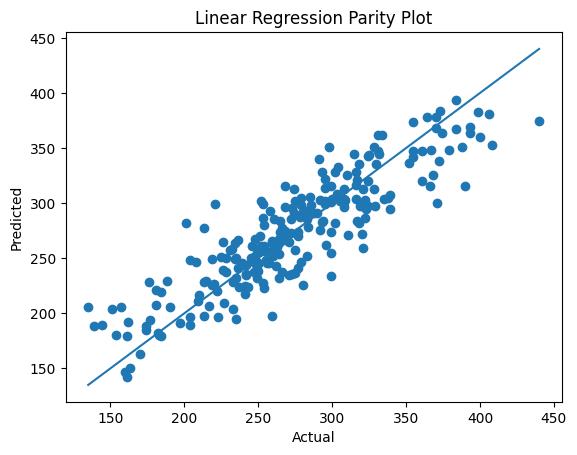

In [14]:
#Parity Plot (Linear)
plt.scatter(y_test, lr_preds)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression Parity Plot")
plt.show()

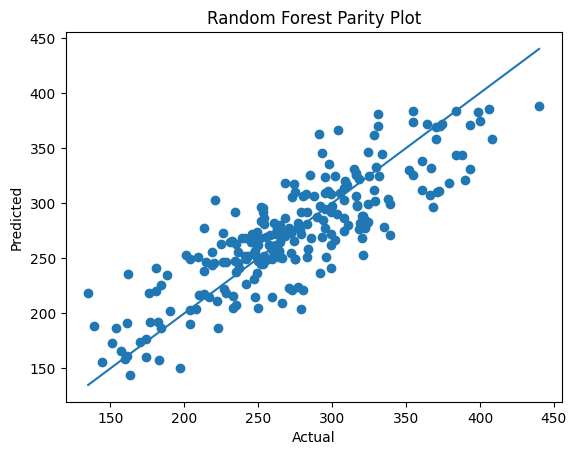

In [15]:
#Parity Plot (Random Forest)
plt.scatter(y_test, rf_preds)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest Parity Plot")
plt.show()

The Linear Regression model shows predictions more closely aligned with the diagonal line, showing better accuracy.
The Random Forest model shows slightly higher deviation, indicating less precise predictions on the Test data

In [16]:
#Feature Importance
rf_model = rf_pipeline.named_steps['model']
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

importances = rf_model.feature_importances_

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feat_imp.head(10)

,feature,importance
7,cat__store_size_small,0.183954
10,num__is_festival,0.174477
5,cat__location_type_urban,0.140498
14,num__day_of_week,0.090612
9,num__is_weekend,0.063547
8,num__store_id,0.062056
6,cat__store_size_medium,0.058178
11,num__competition_density,0.053486
13,num__month,0.040473
4,cat__location_type_semi-urban,0.038886


The most important features influencing sales include store size (small stores), festival periods and urban places.

This suggests that smaller stores may respond more strongly to promotions, while festivals significantly increase customer purchasing behaviour.
also, location plays a key role, with urban stores showing higher impact, likely due to demand patterns.
Temporal factors such as day of the week and weekends also contribute, indicating that customer activity varies across time.

Overall, both store characteristics and timing-related factors are critical in predicting sales performance